# Notebook 02 — EDA and Dataset Understanding

## 1. Notebook Purpose

This notebook explores the raw/lightly prepared datasets visually and statistically,
**before** any heavy cleaning or final variable engineering (that happens in
notebook 03). The goal is to understand:

- what data is available,
- what variables exist and what they look like,
- what is missing and how,
- how employment is distributed overall and across key groups,
- whether the dataset is suitable for the thesis's determinants-of-employment analysis.

**Boundaries (see `instructions.md` §7)**
- No heavy cleaning, no final research variables, no interaction terms.
- No saving of a final modelling dataset (that is notebook 03's job).
- No econometric or machine learning models (notebooks 04–07).
- No fake data and no simulated results. If a required file is missing, this
  notebook stops with a clear message instead of continuing.

**Outputs saved by this notebook**
- Figures → `outputs/figures/`
- Summary tables → `outputs/tables/eda_summary.xlsx`
- Written findings → `outputs/reports/eda_findings.md`

## 2. Environment Setup and Dataset Loading

Run the install cell below **once** if you get a `ModuleNotFoundError` (for
example, `No module named 'pandas'`) — skip it if packages are already installed.
Make sure the correct kernel/virtual environment is selected in VS Code before
running any other cell. Full setup instructions:
[docs/environment_setup.md](../docs/environment_setup.md).

In [26]:
# OPTIONAL: run only if a package is missing (e.g. ModuleNotFoundError: No module named 'pandas').
# Safe to skip if all packages in requirements.txt are already installed in this kernel.
from pathlib import Path

_project_root_for_install = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
_requirements_path = _project_root_for_install / 'requirements.txt'

if not _requirements_path.exists():
    print(f'requirements.txt not found at {_requirements_path}. See docs/environment_setup.md.')
else:
    %pip install -r "{_requirements_path}"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports and path setup for this notebook (EDA: pandas, numpy, matplotlib, seaborn, missingno, scipy).
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import missingno as msno
    from scipy.stats import skew
except ImportError as exc:
    raise ImportError(
        f"Missing package: {exc.name}. Run the optional install cell above (or "
        "`pip install -r requirements.txt` in a terminal), then restart the kernel and re-run this cell."
    ) from exc

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
PICKLE_DIR = DATA_DIR / 'pickle'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
TABLES_DIR = OUTPUTS_DIR / 'tables'
REPORTS_DIR = OUTPUTS_DIR / 'reports'
MODELS_DIR = OUTPUTS_DIR / 'models'
for d in [PROCESSED_DIR, PICKLE_DIR, FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
findings = []  # short markdown bullet strings, collected as the notebook runs and written to eda_findings.md at the end
eda_tables = {}  # sheet_name -> DataFrame, collected and written to eda_summary.xlsx at the end

def add_finding(text):
    findings.append(text)
    print('Finding recorded:', text)

print('Project root:', PROJECT_ROOT)

Project root: c:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis


In [3]:
# ESS11 CSV is checked first (currently available format for this project), with the
# SPSS .sav format accepted as a fallback for either round. pyreadstat is only
# imported if a .sav file actually needs to be read, so CSV-only setups do not
# require it to be installed.
ess_candidates = [
    RAW_DIR / 'ess' / 'ESS11.csv',
    RAW_DIR / 'ess' / 'ESS11.sav',
    RAW_DIR / 'ess' / 'ESS10.csv',
    RAW_DIR / 'ess' / 'ESS10.sav',
]
ess_path = next((p for p in ess_candidates if p.exists()), None)

if ess_path is None:
    raise FileNotFoundError(
        'Required ESS raw file not found in data/raw/ess/. Expected one of: '
        f"{[p.name for p in ess_candidates]}. "
        'Run notebooks/01_dataset_sources_and_description.ipynb and follow the manual '
        'download instructions there. Do not proceed with simulated data.'
    )

if ess_path.suffix == '.csv':
    df_ess = pd.read_csv(ess_path, low_memory=False)
    meta_ess = None  # SPSS variable/value labels are only available when loading a .sav file
else:
    try:
        import pyreadstat
    except ImportError as exc:
        raise ImportError(
            f"Missing package: {exc.name}. Run the optional install cell above (or "
            "`pip install -r requirements.txt` in a terminal), then restart the kernel and re-run this cell."
        ) from exc
    df_ess, meta_ess = pyreadstat.read_sav(ess_path)

print('Loaded ESS file:', ess_path)
print('Shape:', df_ess.shape)

Loaded ESS file: c:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\data\raw\ess\ESS11.csv
Shape: (50116, 691)


In [4]:
eurostat_files = list((RAW_DIR / 'eurostat_ai').glob('*.csv'))

if not eurostat_files:
    print('No Eurostat AI adoption file found in data/raw/eurostat_ai/.')
    print('AI adoption sections of this notebook will be skipped. Run notebook 01 first to check/retrieve it.')
    df_ai = None
else:
    df_ai = pd.read_csv(eurostat_files[0])
    print('Loaded Eurostat AI adoption file:', eurostat_files[0])
    print('Shape:', df_ai.shape)

Loaded Eurostat AI adoption file: c:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\data\raw\eurostat_ai\isoc_eb_ai.csv
Shape: (620, 10)


## 3. Dataset Shape and Column Overview

In [5]:
print('ESS shape (rows, columns):', df_ess.shape)
df_ess.head()

ESS shape (rows, columns): (50116, 691)


,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,rinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
0,ESS11e04_2,11,4.2,02.07.2026,50014,AT,1.185115,0.392891,0.330915,0.130013,...,NaN,2023-11-12 15:26:55,2023-11-12 15:21:28,2023-11-12 15:26:55,30.0,1,2.0,0.000579,107,317
1,ESS11e04_2,11,4.2,02.07.2026,50030,AT,0.609898,0.325153,0.330915,0.107598,...,NaN,2023-10-18 10:44:18,2023-10-18 10:42:22,2023-10-18 10:44:18,40.0,1,1.0,0.001124,69,128
2,ESS11e04_2,11,4.2,02.07.2026,50057,AT,1.392330,4.000023,0.330915,1.323666,...,NaN,2023-09-30 14:13:33,2023-09-30 14:08:31,2023-09-30 14:13:33,42.0,1,2.0,0.000493,18,418
3,ESS11e04_2,11,4.2,02.07.2026,50106,AT,0.556062,0.176228,0.330915,0.058316,...,NaN,2023-06-30 15:11:21,2023-06-30 15:08:05,2023-06-30 15:11:21,34.0,1,1.0,0.001233,101,295
4,ESS11e04_2,11,4.2,02.07.2026,50145,AT,0.722795,1.060940,0.330915,0.351080,...,NaN,2023-07-11 11:14:03,2023-07-11 11:10:02,2023-07-11 11:14:03,57.0,1,2.0,0.000949,115,344


In [6]:
print(f'Total columns: {len(df_ess.columns)}')
print('First 40 column names:')
print(list(df_ess.columns[:40]))

Total columns: 691
First 40 column names:
['name', 'essround', 'edition', 'proddate', 'idno', 'cntry', 'dweight', 'pspwght', 'pweight', 'anweight', 'nwspol', 'netusoft', 'netustm', 'ppltrst', 'pplfair', 'pplhlp', 'polintr', 'psppsgva', 'actrolga', 'psppipla', 'cptppola', 'trstprl', 'trstlgl', 'trstplc', 'trstplt', 'trstprt', 'trstep', 'trstun', 'vote', 'prtvtdat', 'prtvtebe', 'prtvtfbg', 'prtvtchr', 'prtvtccy', 'prtvtiee', 'prtvtffi', 'prtvtffr', 'prtvgde1', 'prtvgde2', 'prtvtegr']


## 4. Data Types

In [7]:
dtype_counts = df_ess.dtypes.value_counts()
print('Column count by data type:')
print(dtype_counts)
df_ess.dtypes.to_frame('dtype')

Column count by data type:
int64      387
float64    280
str         24
Name: count, dtype: int64


,dtype
name,str
essround,int64
edition,float64
proddate,str
idno,int64
...,...
mode,int64
domain,float64
prob,float64
stratum,int64


## 5. Missing Values Analysis

In [8]:
missing_counts = df_ess.isna().sum()
missing_pct = (df_ess.isna().mean() * 100)
missing_table = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0].sort_values('missing_pct', ascending=False)

eda_tables['missing_values'] = missing_table.reset_index().rename(columns={'index': 'column'})
print(f'{len(missing_table)} of {df_ess.shape[1]} columns have at least one missing value.')
missing_table.head(20)

289 of 691 columns have at least one missing value.


,missing_count,missing_pct
rshipa15,50115,99.998005
edlvfgcy,49431,98.633171
edlvgcy,49431,98.633171
prtvtccy,49431,98.633171
edlvpgcy,49431,98.633171
rlgdecy,49431,98.633171
edlvmgcy,49431,98.633171
rlgdncy,49431,98.633171
prtclccy,49431,98.633171
prtcleis,49274,98.319898


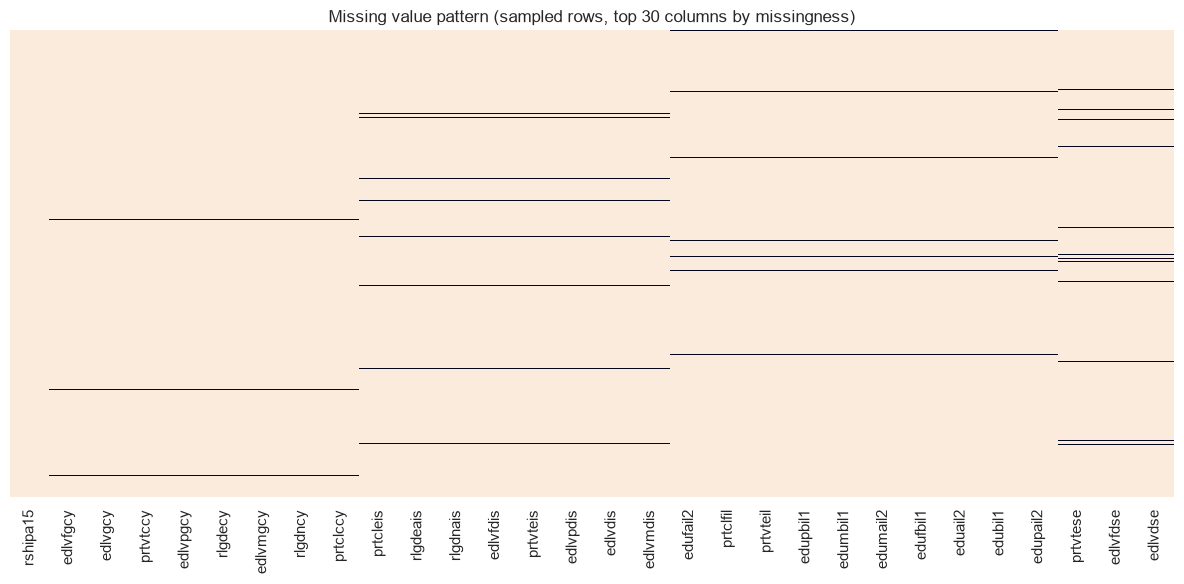

In [9]:
# Heatmap of missingness for the top 30 columns with the most missing values, sampling
# rows for readability if the dataset is large.
top_missing_cols = missing_table.head(30).index.tolist()
sample_df = df_ess[top_missing_cols].sample(n=min(2000, len(df_ess)), random_state=42) if top_missing_cols else pd.DataFrame()

if not sample_df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(sample_df.isna(), cbar=False, yticklabels=False, ax=ax)
    ax.set_title('Missing value pattern (sampled rows, top 30 columns by missingness)')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'missing_values_heatmap.png', dpi=150)
    plt.show()
else:
    print('No missing values found; heatmap skipped.')

In [10]:
if not missing_table.empty:
    add_finding(
        f"{len(missing_table)} columns have missing values; the highest is "
        f"'{missing_table.index[0]}' at {missing_table['missing_pct'].iloc[0]:.1f}% missing."
    )
else:
    add_finding('No missing values detected in the raw ESS file.')

Finding recorded: 289 columns have missing values; the highest is 'rshipa15' at 100.0% missing.


## 6. Target/Employment Variable Exploration

The employment status column below is used **only for exploration in this
notebook**. The official `employed` variable is defined and saved in notebook 03 —
verify the column and code against the ESS codebook before trusting these charts.

C:\Users\khamidov.m\AppData\Local\Temp\ipykernel_33232\746575011.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ess['_employed_temp'] = np.where(df_ess[COL_EMPLOYMENT_STATUS] == EMPLOYED_CODE, 1, 0)


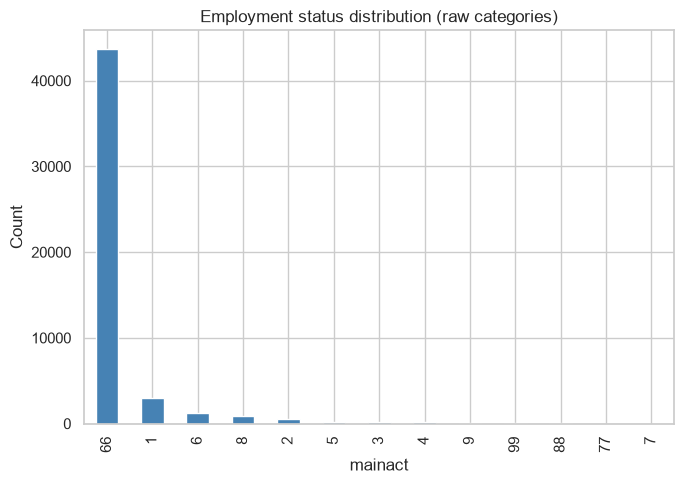

Finding recorded: Overall employment share (raw, pre-cleaning): 6.0%.


In [11]:
# TODO: verify this column name and the 'employed' response code against the ESS codebook.
COL_EMPLOYMENT_STATUS = 'mainact'
EMPLOYED_CODE = 1

if COL_EMPLOYMENT_STATUS in df_ess.columns:
    df_ess['_employed_temp'] = np.where(df_ess[COL_EMPLOYMENT_STATUS] == EMPLOYED_CODE, 1, 0)

    status_counts = df_ess[COL_EMPLOYMENT_STATUS].value_counts(dropna=False)
    employed_share = df_ess['_employed_temp'].mean()

    fig, ax = plt.subplots(figsize=(7, 5))
    status_counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Employment status distribution (raw categories)')
    ax.set_ylabel('Count')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'employment_status_distribution.png', dpi=150)
    plt.show()

    add_finding(f'Overall employment share (raw, pre-cleaning): {employed_share:.1%}.')
else:
    raise KeyError(
        f'{COL_EMPLOYMENT_STATUS} not found in the ESS data. Update COL_EMPLOYMENT_STATUS '
        'using the ESS codebook before continuing this notebook.'
    )

## 7. Demographic EDA (Gender, Age)

In [12]:
def employment_rate_by_group(df, group_col, title, filename, employment_col='_employed_temp'):
    """Reusable helper: computes and plots the employment rate by a grouping column,
    saves the figure, and returns the rate as a Series (or None if columns are missing).
    Used consistently across sections 7-13 so every breakdown follows the same logic."""
    if group_col not in df.columns or employment_col not in df.columns:
        print(f'Skipped "{title}": required column(s) missing ({group_col}).')
        return None

    rate = df.groupby(group_col)[employment_col].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Employment rate')
    ax.set_xlabel(group_col)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150)
    plt.show()

    return rate

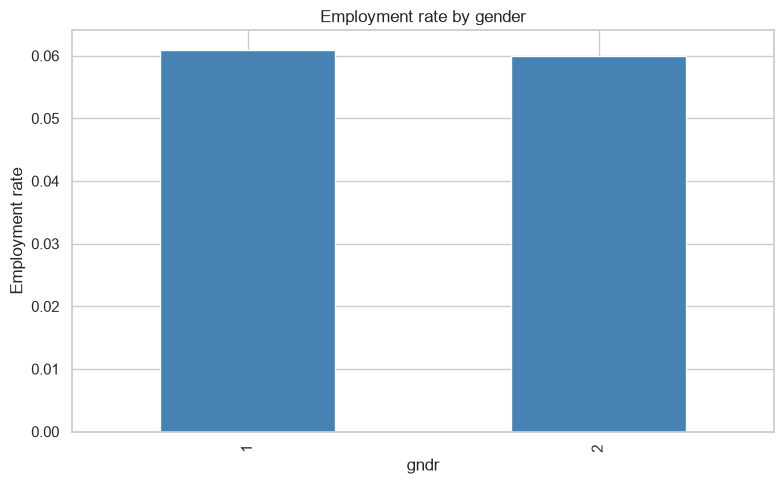

gndr
1    0.060981
2    0.059977
Name: _employed_temp, dtype: float64

In [13]:
# TODO: verify against the ESS codebook.
COL_GENDER = 'gndr'
COL_AGE = 'agea'

gender_rate = employment_rate_by_group(df_ess, COL_GENDER, 'Employment rate by gender', 'employment_by_gender.png')
eda_tables['employment_by_gender'] = gender_rate.reset_index() if gender_rate is not None else pd.DataFrame()
gender_rate

C:\Users\khamidov.m\AppData\Local\Temp\ipykernel_33232\2000179926.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ess['_age_group_temp'] = pd.cut(


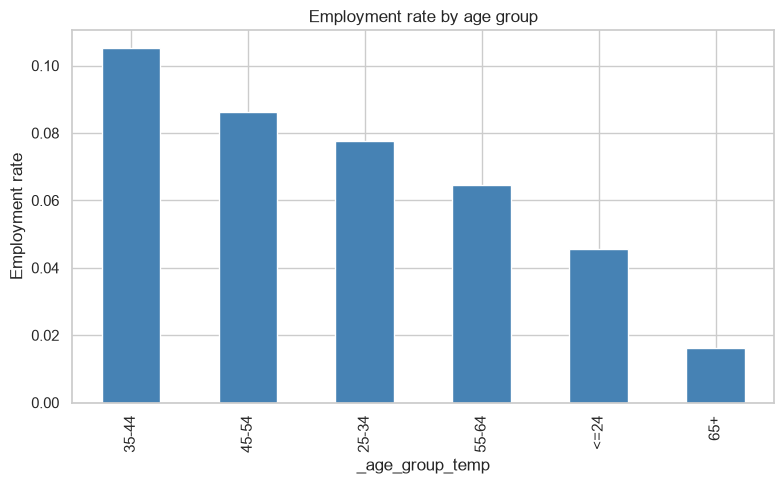

_age_group_temp
35-44    0.105167
45-54    0.086257
25-34    0.077667
55-64    0.064428
<=24     0.045502
65+      0.016229
Name: _employed_temp, dtype: float64

In [14]:
if COL_AGE in df_ess.columns:
    df_ess['_age_group_temp'] = pd.cut(
        df_ess[COL_AGE],
        bins=[0, 24, 34, 44, 54, 64, 120],
        labels=['<=24', '25-34', '35-44', '45-54', '55-64', '65+'],
    )
    age_rate = employment_rate_by_group(df_ess, '_age_group_temp', 'Employment rate by age group', 'employment_by_age_group.png')
    eda_tables['employment_by_age_group'] = age_rate.reset_index() if age_rate is not None else pd.DataFrame()
else:
    print('Age column not found; age group chart skipped.')
    age_rate = None
age_rate

In [15]:
if gender_rate is not None:
    gap = gender_rate.max() - gender_rate.min()
    add_finding(f'Employment rate gap across gender categories: {gap:.1%}.')
if age_rate is not None:
    add_finding(f'Employment rate peaks in the "{age_rate.idxmax()}" age group and is lowest in "{age_rate.idxmin()}".')

Finding recorded: Employment rate gap across gender categories: 0.1%.
Finding recorded: Employment rate peaks in the "35-44" age group and is lowest in "65+".


## 8. Education and Employment EDA

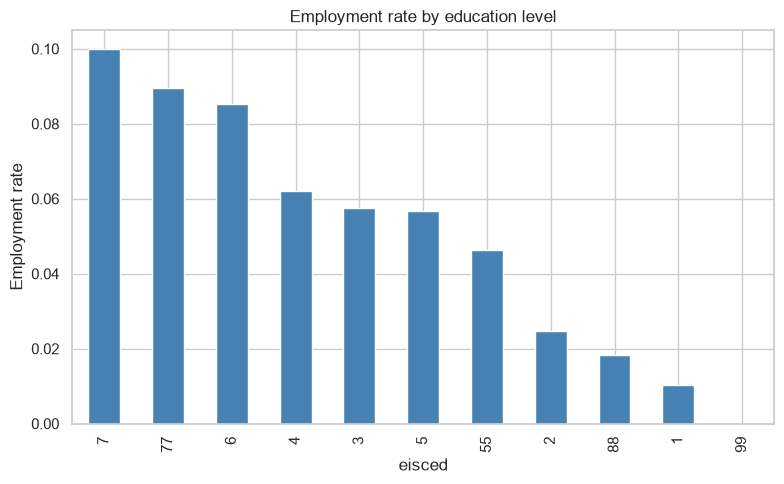

eisced
7     0.099905
77    0.089431
6     0.085187
4     0.062053
3     0.057589
5     0.056652
55    0.046243
2     0.024649
88    0.018182
1     0.010230
99    0.000000
Name: _employed_temp, dtype: float64

In [16]:
# TODO: verify against the ESS codebook.
COL_EDUCATION_LEVEL = 'eisced'
COL_EDUCATION_YEARS = 'eduyrs'

education_rate = employment_rate_by_group(df_ess, COL_EDUCATION_LEVEL, 'Employment rate by education level', 'employment_by_education.png')
eda_tables['employment_by_education'] = education_rate.reset_index() if education_rate is not None else pd.DataFrame()
education_rate

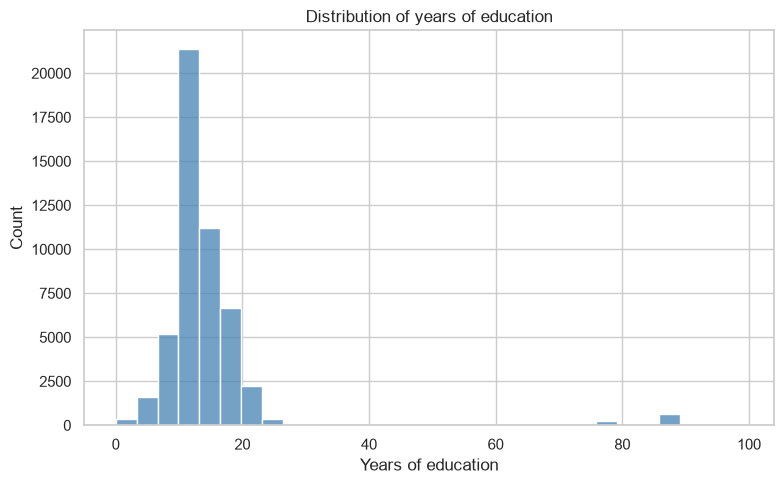

Finding recorded: Highest employment rate education category: 7; lowest: 99.


In [17]:
if COL_EDUCATION_YEARS in df_ess.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df_ess[COL_EDUCATION_YEARS].dropna(), bins=30, ax=ax, color='steelblue')
    ax.set_title('Distribution of years of education')
    ax.set_xlabel('Years of education')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'education_years_distribution.png', dpi=150)
    plt.show()

    if education_rate is not None:
        add_finding(f'Highest employment rate education category: {education_rate.idxmax()}; lowest: {education_rate.idxmin()}.')
else:
    print('Education years column not found; distribution plot skipped.')

## 9. Family and Marital Status EDA

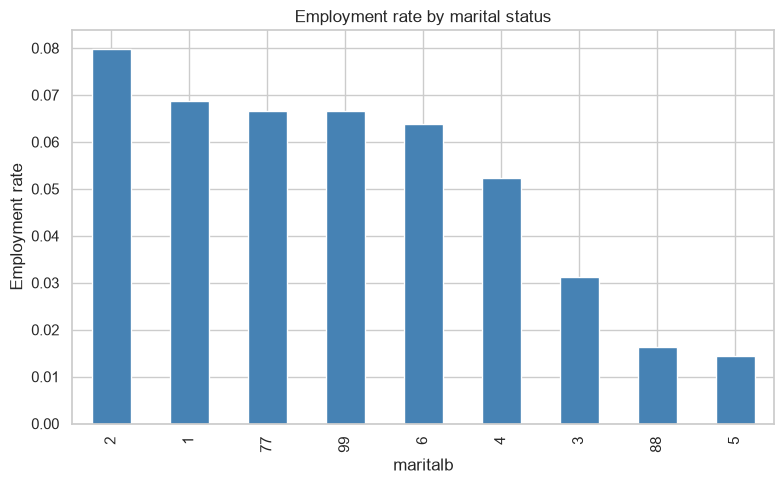

maritalb
2     0.079767
1     0.068795
77    0.066667
99    0.066667
6     0.063791
4     0.052394
3     0.031339
88    0.016393
5     0.014328
Name: _employed_temp, dtype: float64

In [18]:
# TODO: verify against the ESS codebook.
COL_MARITAL = 'maritalb'
COL_HOUSEHOLD_SIZE = 'hhmmb'

marital_rate = employment_rate_by_group(df_ess, COL_MARITAL, 'Employment rate by marital status', 'employment_by_marital_status.png')
eda_tables['employment_by_marital_status'] = marital_rate.reset_index() if marital_rate is not None else pd.DataFrame()
marital_rate

In [19]:
if COL_HOUSEHOLD_SIZE in df_ess.columns and COL_GENDER in df_ess.columns:
    cross_tab = pd.crosstab(df_ess[COL_GENDER], pd.cut(df_ess[COL_HOUSEHOLD_SIZE], bins=[0, 1, 2, 3, 4, 20]), normalize='index')
    eda_tables['gender_by_household_size'] = cross_tab.reset_index()
    print('Cross-tabulation: gender x household size (row percentages)')
    cross_tab
else:
    print('Household size or gender column not found; cross-tabulation skipped.')

Cross-tabulation: gender x household size (row percentages)


## 10. Migration Background EDA

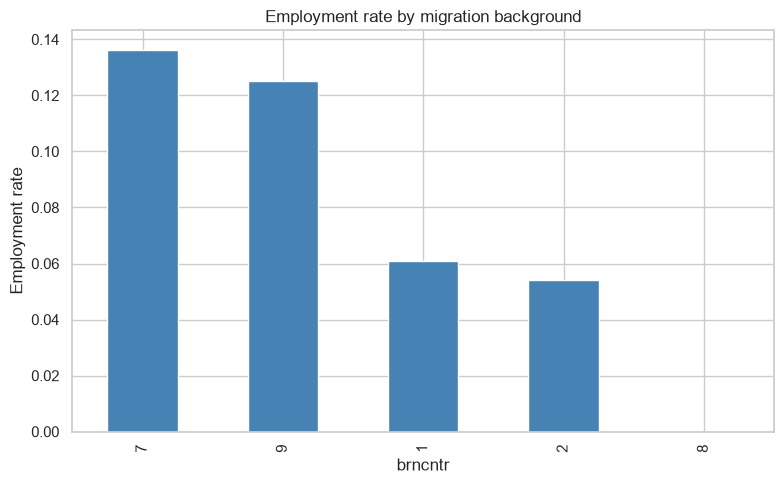

Finding recorded: Employment rate gap by migration background: 13.6% (H4 relevance: check whether education/digital readiness narrow this gap in notebook 03-05).


brncntr
7    0.136364
9    0.125000
1    0.061020
2    0.054220
8    0.000000
Name: _employed_temp, dtype: float64

In [20]:
# TODO: verify against the ESS codebook.
COL_MIGRATION = 'brncntr'

migration_rate = employment_rate_by_group(df_ess, COL_MIGRATION, 'Employment rate by migration background', 'employment_by_migration_background.png')
eda_tables['employment_by_migration'] = migration_rate.reset_index() if migration_rate is not None else pd.DataFrame()
if migration_rate is not None:
    gap = migration_rate.max() - migration_rate.min()
    add_finding(f'Employment rate gap by migration background: {gap:.1%} (H4 relevance: check whether education/digital readiness narrow this gap in notebook 03-05).')
migration_rate

## 11. Health EDA

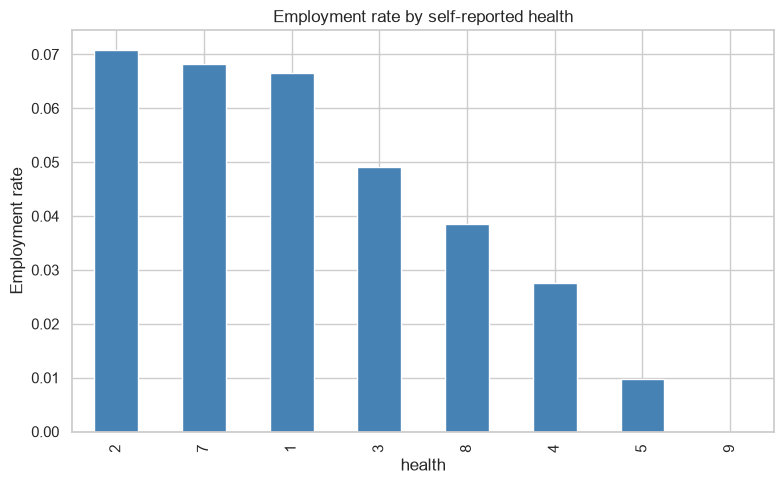

health
2    0.070899
7    0.068182
1    0.066525
3    0.049088
8    0.038462
4    0.027634
5    0.009756
9    0.000000
Name: _employed_temp, dtype: float64

In [21]:
# TODO: verify against the ESS codebook.
COL_HEALTH = 'health'

health_rate = employment_rate_by_group(df_ess, COL_HEALTH, 'Employment rate by self-reported health', 'employment_by_health.png')
eda_tables['employment_by_health'] = health_rate.reset_index() if health_rate is not None else pd.DataFrame()
health_rate

## 12. Internet Use / Digital Readiness EDA

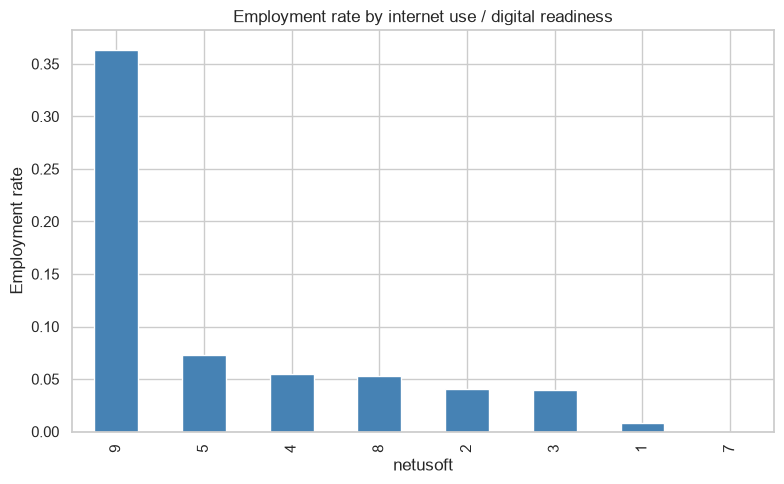

Finding recorded: Employment rate is highest for digital readiness category "9" (H1/H2 relevance).


netusoft
9    0.363636
5    0.072811
4    0.054746
8    0.052632
2    0.040913
3    0.039197
1    0.008031
7    0.000000
Name: _employed_temp, dtype: float64

In [22]:
# TODO: verify against the ESS codebook.
COL_DIGITAL = 'netusoft'

digital_rate = employment_rate_by_group(df_ess, COL_DIGITAL, 'Employment rate by internet use / digital readiness', 'employment_by_digital_readiness.png')
eda_tables['employment_by_digital_readiness'] = digital_rate.reset_index() if digital_rate is not None else pd.DataFrame()
if digital_rate is not None:
    add_finding(f'Employment rate is highest for digital readiness category "{digital_rate.idxmax()}" (H1/H2 relevance).')
digital_rate

## 13. Country-Level EDA

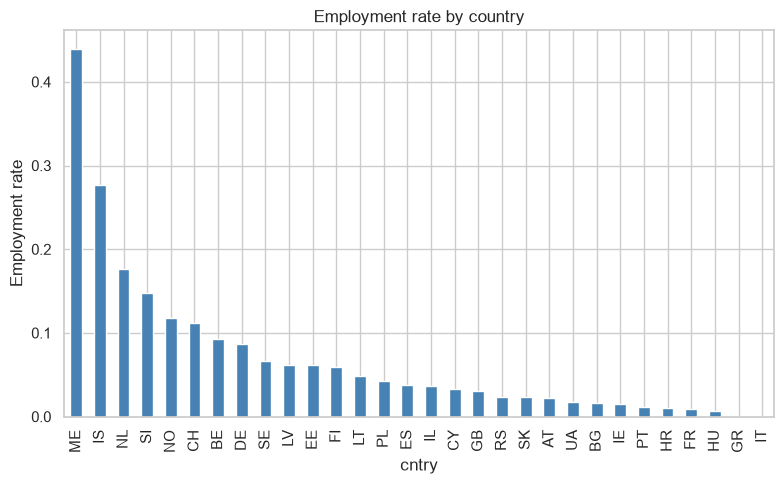

Finding recorded: Country-level employment rate ranges from 0.1% to 43.9%.


cntry
ME    0.439403
IS    0.276722
NL    0.175811
SI    0.147436
NO    0.117427
CH    0.111272
BE    0.092848
DE    0.086364
SE    0.066667
LV    0.061502
EE    0.061098
FI    0.059501
LT    0.048352
PL    0.042996
ES    0.037419
IL    0.036424
CY    0.033577
GB    0.030879
RS    0.023672
SK    0.022885
AT    0.022090
UA    0.017287
BG    0.016079
IE    0.014874
PT    0.010925
HR    0.010877
FR    0.009599
HU    0.006610
GR    0.001088
IT    0.001047
Name: _employed_temp, dtype: float64

In [23]:
# TODO: verify against the ESS codebook.
COL_COUNTRY = 'cntry'

country_rate = employment_rate_by_group(df_ess, COL_COUNTRY, 'Employment rate by country', 'employment_by_country.png')
eda_tables['employment_by_country'] = country_rate.reset_index() if country_rate is not None else pd.DataFrame()
if country_rate is not None:
    add_finding(f'Country-level employment rate ranges from {country_rate.min():.1%} to {country_rate.max():.1%}.')
country_rate

## 14. AI Adoption EDA (if available)

The `eurostat` package typically returns wide-format data with a `geo\TIME_PERIOD` or
`geo` column and one column per time period. Inspect `df_ai.columns` and adjust the
column names below if they differ.

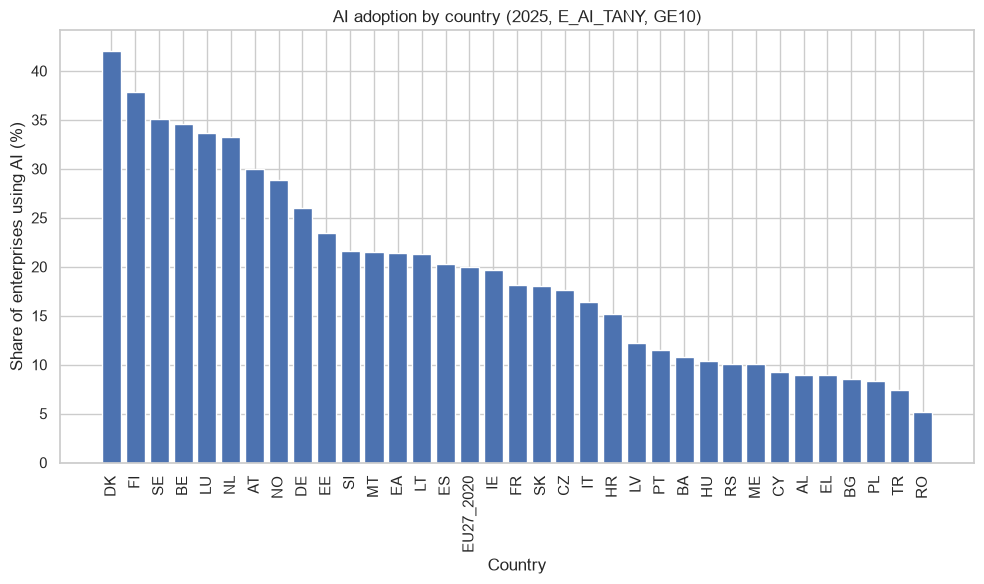

Finding recorded: AI adoption (2025, E_AI_TANY, GE10) ranges from 5.2% to 42.0% across countries.


In [27]:
# The raw Eurostat file is in LONG format: each country has multiple rows, one per
# combination of `indic_is` (AI indicator) and `size_emp` (enterprise size class).
# Selecting only [geo, year] without filtering mixes all these rows together, which
# both breaks numeric formatting (year columns contain Eurostat flags like ':' or
# '@C' for missing/confidential values, so they load as strings) and creates
# duplicate country labels. We filter to a single indicator/size-class combination
# so each country appears exactly once.
AI_INDICATOR = 'E_AI_TANY'  # 'enterprises using any AI technology' — the headline adoption measure
AI_SIZE_CLASS = 'GE10'  # enterprises with >=10 employees (all size classes combined)

geo_col, latest_year_col, df_ai_filtered = None, None, None

if df_ai is None:
    print('Eurostat AI adoption data not available; skipping this section.')
else:
    geo_col_candidates = ['geo\\TIME_PERIOD', 'geo']
    geo_col = next((c for c in geo_col_candidates if c in df_ai.columns), None)
    year_cols = [c for c in df_ai.columns if str(c).isdigit()]
    latest_year_col = max(year_cols) if year_cols else None

    if geo_col is None or latest_year_col is None:
        print('Could not identify the country or year column automatically. Inspect df_ai.columns and adjust this cell.')
    elif 'indic_is' not in df_ai.columns or 'size_emp' not in df_ai.columns:
        print('Could not identify the indic_is/size_emp columns to filter to one row per country. Inspect df_ai.columns and adjust this cell.')
    else:
        df_ai_filtered = df_ai[(df_ai['indic_is'] == AI_INDICATOR) & (df_ai['size_emp'] == AI_SIZE_CLASS)].copy()
        df_ai_filtered[latest_year_col] = pd.to_numeric(df_ai_filtered[latest_year_col], errors='coerce')

        ai_by_country = df_ai_filtered[[geo_col, latest_year_col]].dropna().sort_values(latest_year_col, ascending=False)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.bar(ai_by_country[geo_col].astype(str), ai_by_country[latest_year_col])
        ax.set_title(f'AI adoption by country ({latest_year_col}, {AI_INDICATOR}, {AI_SIZE_CLASS})')
        ax.set_ylabel('Share of enterprises using AI (%)')
        ax.set_xlabel('Country')
        plt.xticks(rotation=90)
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / 'ai_adoption_by_country.png', dpi=150)
        plt.show()

        eda_tables['ai_adoption_by_country'] = ai_by_country
        add_finding(f'AI adoption ({latest_year_col}, {AI_INDICATOR}, {AI_SIZE_CLASS}) ranges from {ai_by_country[latest_year_col].min():.1f}% to {ai_by_country[latest_year_col].max():.1f}% across countries.')

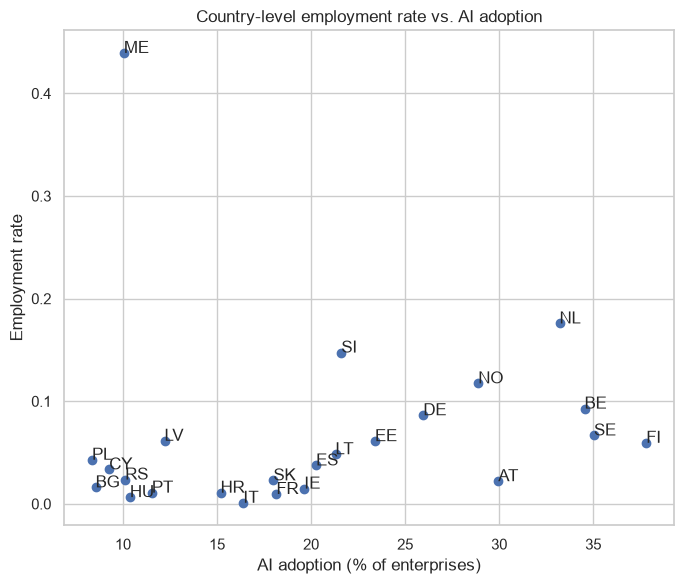

In [28]:
if country_rate is not None and geo_col is not None and latest_year_col is not None and df_ai_filtered is not None:
    employment_by_country = df_ess.groupby(COL_COUNTRY)['_employed_temp'].mean().rename('employment_rate')
    ai_by_country_series = df_ai_filtered.dropna(subset=[latest_year_col]).set_index(geo_col)[latest_year_col].rename('ai_adoption_pct')
    country_comparison = pd.concat([employment_by_country, ai_by_country_series], axis=1, join='inner')

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(country_comparison['ai_adoption_pct'], country_comparison['employment_rate'])
    for country_code, row in country_comparison.iterrows():
        ax.annotate(str(country_code), (row['ai_adoption_pct'], row['employment_rate']))
    ax.set_xlabel('AI adoption (% of enterprises)')
    ax.set_ylabel('Employment rate')
    ax.set_title('Country-level employment rate vs. AI adoption')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'employment_vs_ai_adoption_country_level.png', dpi=150)
    plt.show()

    eda_tables['employment_vs_ai_adoption'] = country_comparison.reset_index()
else:
    print('Skipped employment-vs-AI-adoption comparison: required data not available.')

## 15. Correlation and Distribution Analysis

Descriptive statistics, skewness, distribution shapes, outlier checks, and a
correlation heatmap for the key numeric variables identified so far.

In [29]:
numeric_candidates = [c for c in [COL_AGE, COL_EDUCATION_YEARS, COL_HOUSEHOLD_SIZE, COL_DIGITAL, COL_HEALTH] if c in df_ess.columns]

descriptive_stats = df_ess[numeric_candidates].describe().T
descriptive_stats['skewness'] = df_ess[numeric_candidates].apply(lambda s: skew(s.dropna()))
eda_tables['descriptive_statistics'] = descriptive_stats.reset_index().rename(columns={'index': 'variable'})
descriptive_stats

,count,mean,std,min,25%,50%,75%,max,skewness
agea,50116.0,59.023126,85.610075,15.0,37.0,53.0,67.0,999.0,10.366489
eduyrs,50116.0,14.542601,10.397933,0.0,11.0,13.0,16.0,99.0,5.756642
hhmmb,50116.0,3.041723,6.408661,0.0,2.0,2.0,3.0,99.0,11.378867
netusoft,50116.0,4.201912,1.423663,1.0,4.0,5.0,5.0,9.0,-1.467692
health,50116.0,2.197342,0.943038,1.0,2.0,2.0,3.0,9.0,0.723146


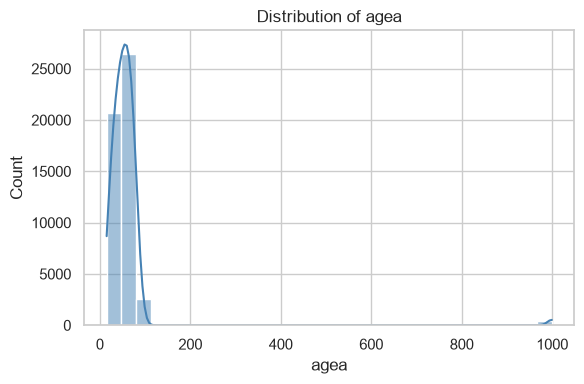

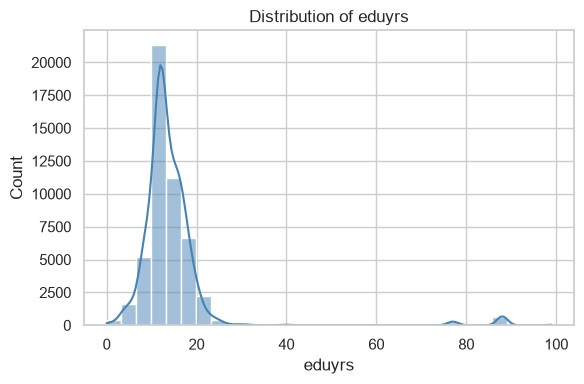

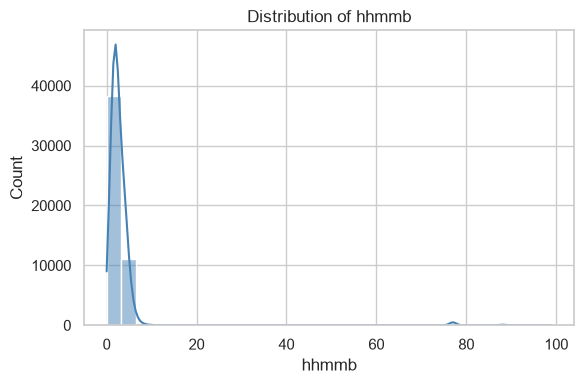

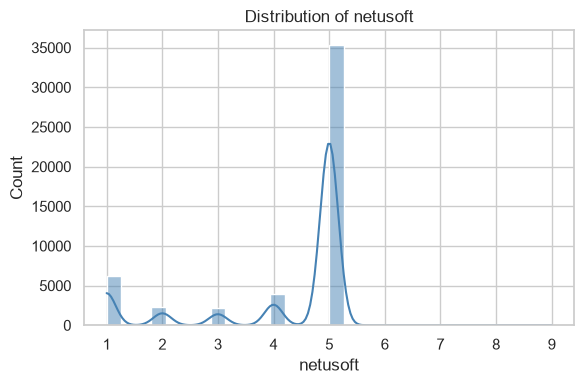

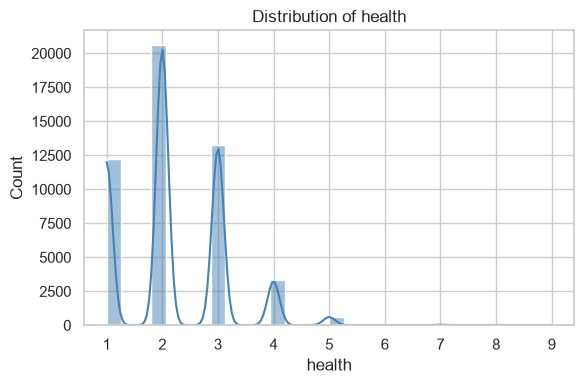

In [30]:
for col in numeric_candidates:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(df_ess[col].dropna(), bins=30, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'distribution_{col}.png', dpi=150)
    plt.show()

In [31]:
# Simple outlier check via the IQR rule, for information only (no rows are dropped here).
outlier_summary_rows = []
for col in numeric_candidates:
    series = df_ess[col].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    outlier_summary_rows.append({'variable': col, 'lower_bound': lower, 'upper_bound': upper, 'n_outliers': n_outliers, 'pct_outliers': n_outliers / len(series) * 100})

outlier_summary = pd.DataFrame(outlier_summary_rows)
eda_tables['outlier_summary'] = outlier_summary
outlier_summary

,variable,lower_bound,upper_bound,n_outliers,pct_outliers
0,agea,-8.0,112.0,393,0.784181
1,eduyrs,3.5,23.5,1836,3.663501
2,hhmmb,0.5,4.5,4346,8.671881
3,netusoft,2.5,6.5,8598,17.156198
4,health,0.5,4.5,691,1.378801


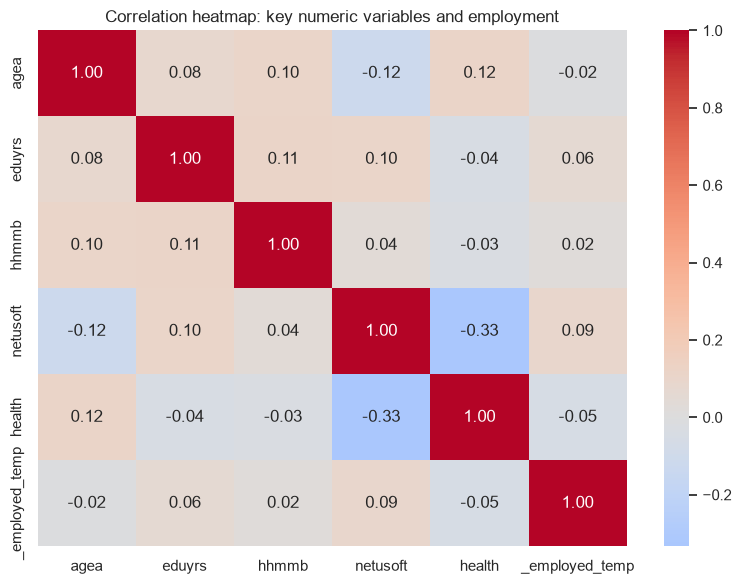

In [32]:
if len(numeric_candidates) > 1:
    corr_matrix = df_ess[numeric_candidates + ['_employed_temp']].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    ax.set_title('Correlation heatmap: key numeric variables and employment')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150)
    plt.show()
    eda_tables['correlation_matrix'] = corr_matrix.reset_index().rename(columns={'index': 'variable'})
else:
    print('Not enough numeric variables identified yet for a correlation heatmap.')

## 16. Main EDA Findings

All findings recorded with `add_finding()` throughout this notebook are written to
`outputs/reports/eda_findings.md`, alongside the summary tables saved to
`outputs/tables/eda_summary.xlsx`.

In [33]:
eda_summary_path = TABLES_DIR / 'eda_summary.xlsx'
with pd.ExcelWriter(eda_summary_path) as writer:
    for sheet_name, table in eda_tables.items():
        if isinstance(table, pd.DataFrame) and not table.empty:
            table.to_excel(writer, sheet_name=sheet_name[:31], index=False)
print('Saved EDA summary tables to:', eda_summary_path)

Saved EDA summary tables to: c:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\tables\eda_summary.xlsx


In [34]:
findings_path = REPORTS_DIR / 'eda_findings.md'
with open(findings_path, 'w', encoding='utf-8') as f:
    f.write('# EDA Findings\n\n')
    f.write('Generated by notebooks/02_eda_dataset_understanding.ipynb.\n\n')
    f.write('## Key Observations\n\n')
    for item in findings:
        f.write(f'- {item}\n')
    f.write('\n## Suitability for the Thesis\n\n')
    f.write(
        'Based on the observations above, note here whether the dataset appears suitable '
        'for testing H1-H5 (sample size per country, variable coverage, missingness levels), '
        'and flag any concern to resolve before notebook 03.\n'
    )

print('Saved EDA findings to:', findings_path)
print('Next step: notebooks/03_data_engineering_and_final_dataset.ipynb')

Saved EDA findings to: c:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\reports\eda_findings.md
Next step: notebooks/03_data_engineering_and_final_dataset.ipynb
